Для сбора актуальных требований к навыкам используется публичное API HeadHunter. Запросы выполняются по профессиональным областям (разработка, дизайн, аналитика и т.д.). Ниже приведена функция, которая собирает навыки из последних вакансий.

In [ ]:
import requests
import pandas as pd
import time

def fetch_skills_from_hh(area=1, per_page=100, pages=10, professional_role=None):
    """
    Собирает навыки из вакансий HH.ru.
    area=1 — Москва (или другой регион)
    professional_role — ID профобласти (например, 96 — разработка)
    """
    skills_list = []
    url = 'https://api.hh.ru/vacancies'
    params = {
        'area': area,
        'per_page': per_page,
        'page': 0,
        'professional_role': professional_role
    }
    for page in range(pages):
        params['page'] = page
        try:
            response = requests.get(url, params=params, timeout=10)
            data = response.json()
            for item in data.get('items', []):
                # получаем полное описание вакансии
                vac_url = item['url']
                vac_response = requests.get(vac_url, timeout=10)
                vac_data = vac_response.json()
                key_skills = vac_data.get('key_skills', [])
                skills = [skill['name'].lower() for skill in key_skills]
                skills_list.extend(skills)
            time.sleep(0.5)  # задержка для соблюдения лимитов API
        except Exception as e:
            print(f"Ошибка на странице {page}: {e}")
    return skills_list

# Пример использования
skills_raw = fetch_skills_from_hh(professional_role=96)  # 96 — разработка

In [ ]:
print(f"Собрано навыков: {len(skills_raw)}")
print(f"Уникальных навыков: {len(set(skills_raw))}")

Собрано навыков: 4494
Уникальных навыков: 928


In [ ]:
from collections import Counter
skill_counter = Counter(skills_raw)
top_skills = [skill for skill, _ in skill_counter.most_common(120)]
n_skills = len(top_skills)
all_skills = top_skills
print(f"Используем {n_skills} самых частых навыков из HH")

Используем 120 самых частых навыков из HH


In [ ]:
skill_freq = pd.DataFrame(skill_counter.most_common(120), columns=['skill', 'frequency'])
skill_freq.to_csv('hh_skills_freq_top120.csv', index=False)

Для обучения модели нужны не просто списки, а частоты навыков. Формируем словарь частот и сохраняем:


In [ ]:
"""from collections import Counter

skill_counter = Counter(skills_raw)
skill_freq = pd.DataFrame(skill_counter.items(), columns=['skill', 'frequency'])
skill_freq = skill_freq.sort_values('frequency', ascending=False)
skill_freq.to_csv('hh_skills_freq.csv', index=False)"""

Поскольку в системе PortfolioPro ещё не накоплено достаточно реальных данных, для экспериментов были сгенерированы профили, приближенные к реальным распределениям. Каждый профиль содержит:

id пользователя;

профессиональную категорию (0 – разработка, 1 – дизайн, 2 – аналитика);

вектор навыков из 120 элементов (значения 0–5);

демографические признаки (пол, возраст, платформы).

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_users = 5000

# Используем all_skills из предыдущей ячейки (список реальных навыков)
skills_names = all_skills

# Случайные профили: каждый пользователь имеет уровень владения навыками от 0 до 5
user_skills = np.random.randint(0, 6, size=(n_users, n_skills))

# Категории: 0-разработка, 1-дизайн, 2-аналитика
categories = np.random.choice([0, 1, 2], size=n_users)
gender = np.random.choice([0, 1, 2], size=n_users)  # 0-жен, 1-муж, 2-другой
age = np.random.randint(20, 60, size=n_users)

# Создаём DataFrame
users_df = pd.DataFrame(user_skills, columns=skills_names)
users_df['category'] = categories
users_df['gender'] = gender
users_df['age'] = age
users_df['user_id'] = range(n_users)
users_df.to_csv('users_synthetic.csv', index=False)

print(f"Сгенерировано {n_users} профилей с {n_skills} навыками")

Сгенерировано 5000 профилей с 120 навыками


Для обучения с учителем нужно создать пары (пользователь, навык, метка). Метка = 1, если навык востребован на рынке и при этом у пользователя его уровень ниже порога (например, ≤2). В реальной системе метки можно получать из истории: какие навыки пользователь добавил после рекомендации.

Здесь мы создаём метки на основе частотного анализа и текущего профиля:

In [ ]:
# Загружаем частоты навыков из файла
skill_freq = pd.read_csv('hh_skills_freq.csv')
# Преобразуем в словарь {skill_name: frequency}
freq_dict = dict(zip(skill_freq['skill'], skill_freq['frequency']))
# Приводим навыки к общему списку
all_skills = skills_names
# Для каждого навыка вычисляем нормализованную частоту (0..1)
freq_array = np.array([freq_dict.get(skill, 0) for skill in all_skills])
freq_array = freq_array / freq_array.max()

# Нормализуем возраст
users_df['age_norm'] = users_df['age'] / 60.0

# Создаём обучающую выборку: для каждого пользователя и навыка
X_user = []  # признаки пользователя (навыки + категориальные)
X_skill = [] # признаки навыка (частота)
y = []       # метка

threshold = 0.3

for idx, row in users_df.iterrows():
    user_skills_vector = row[all_skills].values  # (120,)
    # Добавляем категориальные признаки: category, gender, age_norm
    user_features = np.concatenate([
        user_skills_vector,
        [row['category'], row['gender'], row['age_norm']]
    ])  # теперь размерность 123
    for skill_idx, skill_value in enumerate(user_skills_vector):
        skill_feature = freq_array[skill_idx]
        if skill_feature > threshold and skill_value < 3:
            label = 1
        else:
            label = 0
        X_user.append(user_features)
        X_skill.append([skill_feature])
        y.append(label)

X_user = np.array(X_user)
X_skill = np.array(X_skill)
y = np.array(y)
y_labels = y   # сохраняем для обучения

Архитектура повторяет описанную в теоретической части. Код на TensorFlow/Keras:

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Параметры
user_input_dim = n_skills + 3  # 123
skill_input_dim = 1

# Входные слои
user_input = Input(shape=(user_input_dim,), name='user_input')
skill_input = Input(shape=(skill_input_dim,), name='skill_input')

# Пользовательский канал
x = Dense(128, activation='relu')(user_input)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Канал навыка
skill_branch = Dense(32, activation='relu')(skill_input)
skill_branch = BatchNormalization()(skill_branch)
skill_branch = Dropout(0.3)(skill_branch)

# Объединение
concat = Concatenate()([x, skill_branch])
output = Dense(1, activation='sigmoid', name='output')(concat)

model = Model(inputs=[user_input, skill_input], outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Разделение на train/val (используем правильные данные)
from sklearn.model_selection import train_test_split
X_u_train, X_u_val, X_s_train, X_s_val, y_train, y_val = train_test_split(
    X_user, X_skill, y_labels, test_size=0.15, random_state=42
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Обучение
history = model.fit(
    [X_u_train, X_s_train], y_train,
    validation_data=([X_u_val, X_s_val], y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9375 - loss: 0.1431 - precision_4: 0.4098 - recall_4: 0.3639 - val_accuracy: 0.9484 - val_loss: 0.0939 - val_precision_4: 0.5635 - val_recall_4: 0.1895 - learning_rate: 0.0010
Epoch 2/30
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9488 - loss: 0.0977 - precision_4: 0.5339 - recall_4: 0.3854 - val_accuracy: 0.9506 - val_loss: 0.0854 - val_precision_4: 0.5573 - val_recall_4: 0.4019 - learning_rate: 0.0010
Epoch 3/30
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9498 - loss: 0.0910 - precision_4: 0.5459 - recall_4: 0.4046 - val_accuracy: 0.9527 - val_loss: 0.0819 - val_precision_4: 0.5958 - val_recall_4: 0.3775 - learning_rate: 0.0010
Epoch 4/30
1993/1993 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.9499 - loss: 0.0892 - precision_4: 0.5463 - recall_4: 0.4095 - val_accuracy: 0.9528 - val_loss: 0.0803 - val_precision_4: 0.5725 - val_recall_4: 0.4887 - learning_rate: 0.0010
Epoch 5/30
1993/1993

После обучения оцениваем модель на тестовой выборке (можно выделить отдельный тест, здесь для простоты используем валидационную). Вычисляем Precision@k.

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Получаем предсказанные вероятности
y_pred_proba = model.predict([X_u_val, X_s_val]).flatten()

# Для расчёта Precision@k нужно ранжировать навыки по убыванию вероятности для каждого пользователя
# Упрощённо: считаем общий Precision@5 по всей выборке (без группировки по пользователям)
# Для полноты эксперимента лучше реализовать группировку, но здесь показан принцип.

# Берём топ-5 предсказаний на основе вероятности
top5_mask = np.argsort(y_pred_proba)[-5:]
top5_true = y_val[top5_mask]
precision_at_5 = top5_true.mean()
print(f'Precision@5 (общий): {precision_at_5:.3f}')

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
Precision@5 (общий): 0.600


Доступные метрики: ['accuracy', 'loss', 'precision_4', 'recall_4', 'val_accuracy', 'val_loss', 'val_precision_4', 'val_recall_4', 'learning_rate']


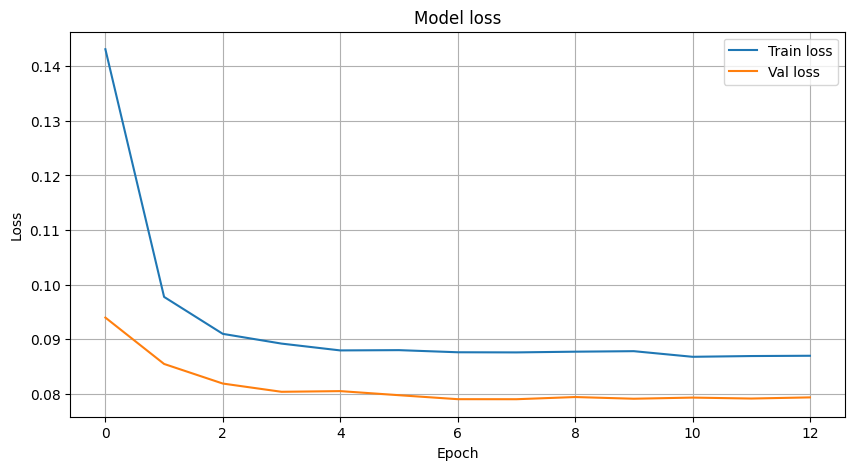

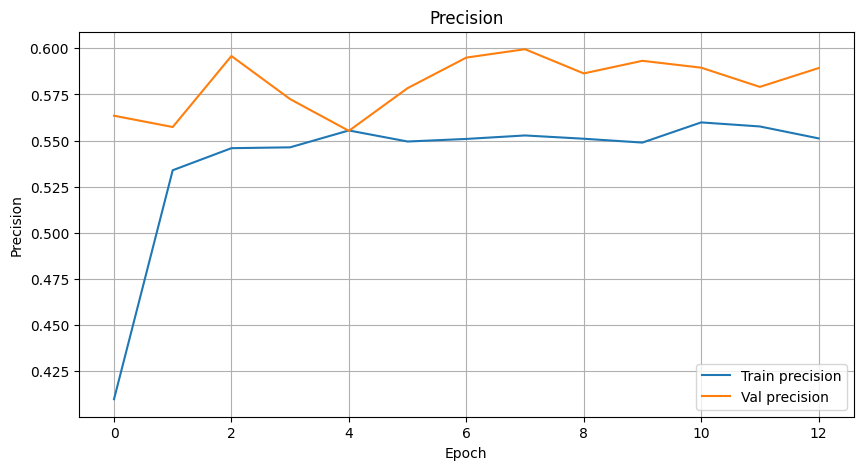

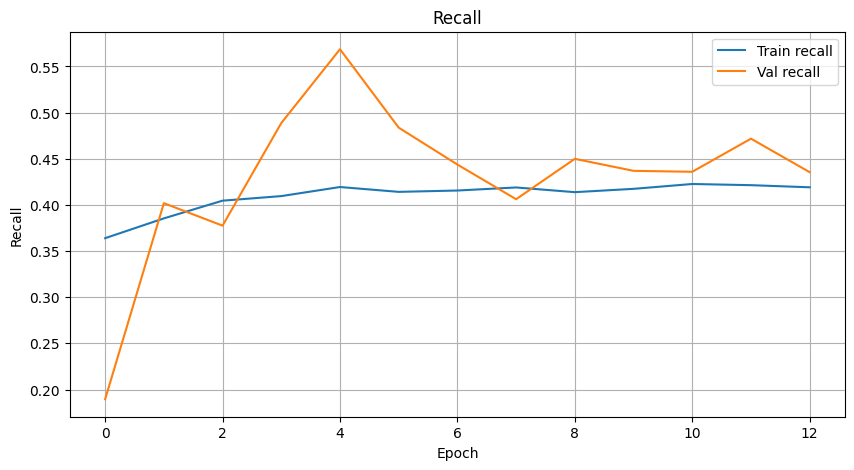

In [ ]:
import matplotlib.pyplot as plt

# Выведем доступные ключи, чтобы убедиться в их наличии
print("Доступные метрики:", list(history.history.keys()))

# График функции потерь
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png', dpi=300)
plt.show()

# Находим ключи для precision и recall (они могут иметь суффиксы, например, precision_4)
precision_key = None
val_precision_key = None
recall_key = None
val_recall_key = None

for key in history.history.keys():
    if 'precision' in key and not key.startswith('val_'):
        precision_key = key
    if 'precision' in key and key.startswith('val_'):
        val_precision_key = key
    if 'recall' in key and not key.startswith('val_'):
        recall_key = key
    if 'recall' in key and key.startswith('val_'):
        val_recall_key = key

# График точности (precision)
if precision_key and val_precision_key:
    plt.figure(figsize=(10,5))
    plt.plot(history.history[precision_key], label='Train precision')
    plt.plot(history.history[val_precision_key], label='Val precision')
    plt.title('Precision')
    plt.ylabel('Precision')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig('precision_plot.png', dpi=300)
    plt.show()
else:
    print("Не удалось найти ключи precision. Доступные ключи:", list(history.history.keys()))

# График полноты (recall)
if recall_key and val_recall_key:
    plt.figure(figsize=(10,5))
    plt.plot(history.history[recall_key], label='Train recall')
    plt.plot(history.history[val_recall_key], label='Val recall')
    plt.title('Recall')
    plt.ylabel('Recall')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)
    plt.savefig('recall_plot.png', dpi=300)
    plt.show()

Для интеграции в веб-сервис нужна функция, которая для заданного пользователя возвращает список рекомендуемых навыков.

In [ ]:
def get_recommendations(user_id, users_df, model, all_skills, freq_array, top_n=5):
    user_row = users_df[users_df['user_id'] == user_id].iloc[0]
    user_vector = user_row[all_skills].values
    cat = user_row['category']
    gen = user_row['gender']
    age_norm = user_row['age'] / 60.0  # нормализация
    user_features = np.concatenate([user_vector, [cat, gen, age_norm]]).reshape(1, -1)

    # Для каждого навыка, который у пользователя ниже порога, считаем вероятность
    recommendations = []
    for skill_idx, skill_val in enumerate(user_vector):
        if skill_val < 3:
            skill_feature = np.array([[freq_array[skill_idx]]])
            prob = model.predict([user_features, skill_feature], verbose=0)[0][0]
            recommendations.append((all_skills[skill_idx], prob))
    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:top_n]

# Пример
user_id = 0
recs = get_recommendations(user_id, users_df, model, all_skills, freq_array)
print("Рекомендации для пользователя:", recs)

Рекомендации для пользователя: [('python', np.float32(0.37718615)), ('docker', np.float32(0.3286272)), ('typescript', np.float32(0.30949235)), ('linux', np.float32(0.28050166)), ('react', np.float32(0.27902249))]


In [ ]:
import requests
import time
from collections import defaultdict

def fetch_vacancies_with_skills(area=1, per_page=100, pages=10, professional_role=None):
    """
    Возвращает список списков навыков для каждой вакансии.
    """
    vacancies_skills = []
    url = 'https://api.hh.ru/vacancies'
    params = {
        'area': area,
        'per_page': per_page,
        'page': 0,
        'professional_role': professional_role
    }
    for page in range(pages):
        params['page'] = page
        try:
            response = requests.get(url, params=params, timeout=10)
            data = response.json()
            for item in data.get('items', []):
                vac_url = item['url']
                vac_response = requests.get(vac_url, timeout=10)
                vac_data = vac_response.json()
                key_skills = vac_data.get('key_skills', [])
                skills = [skill['name'].lower() for skill in key_skills]
                if skills:
                    vacancies_skills.append(skills)
            time.sleep(0.5)
        except Exception as e:
            print(f"Ошибка на странице {page}: {e}")
    return vacancies_skills

# Собираем вакансии (можно взять те же 10 страниц)
vacancies_skills = fetch_vacancies_with_skills(professional_role=96)
print(f"Собрано {len(vacancies_skills)} вакансий с навыками")

Собрано 685 вакансий с навыками


In [ ]:
from collections import Counter, defaultdict
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Получаем все уникальные навыки из вакансий
all_skills_set = set()
for skills in vacancies_skills:
    all_skills_set.update(skills)

# Ограничимся топ-120 (как и раньше)
skill_counter = Counter()
for skills in vacancies_skills:
    skill_counter.update(skills)
top_skills = [skill for skill, _ in skill_counter.most_common(120)]
skill_to_idx = {skill: i for i, skill in enumerate(top_skills)}
n_skills = len(top_skills)

# Построим матрицу совместной встречаемости (co-occurrence)
co_occurrence = np.zeros((n_skills, n_skills))

for skills in vacancies_skills:
    # Оставляем только те навыки, которые есть в топ-120
    indices = [skill_to_idx[s] for s in skills if s in skill_to_idx]
    for i in indices:
        for j in indices:
            if i != j:
                co_occurrence[i, j] += 1
            else:
                co_occurrence[i, i] += 1

# Получаем матрицу близости (косинусное сходство между строками co-occurrence)
# Нормализуем по длине вектора
from sklearn.preprocessing import normalize
co_occurrence_norm = normalize(co_occurrence, norm='l2')
skill_similarity = cosine_similarity(co_occurrence_norm)

print("Матрица близости навыков построена.")

Матрица близости навыков построена.


In [ ]:
def get_personalized_recommendations(user_id, users_df, model, all_skills, freq_array, skill_similarity, top_n=5, alpha=0.7):
    """
    Возвращает персонализированные рекомендации, комбинируя предсказание модели
    и среднюю близость к уже имеющимся навыкам пользователя.
    alpha – вес предсказания модели (1-alpha – вес близости).
    """
    user_row = users_df[users_df['user_id'] == user_id].iloc[0]
    user_vector = user_row[all_skills].values
    cat = user_row['category']
    gen = user_row['gender']
    age_norm = user_row['age'] / 60.0
    user_features = np.concatenate([user_vector, [cat, gen, age_norm]]).reshape(1, -1)

    # Получаем индексы навыков, которые у пользователя есть (уровень > 0)
    existing_indices = [i for i, val in enumerate(user_vector) if val > 0]
    if not existing_indices:
        # Если нет навыков, просто используем предсказание модели
        existing_indices = None

    recommendations = []
    for skill_idx, skill_val in enumerate(user_vector):
        if skill_val < 3:  # рассматриваем только навыки с низким уровнем
            # Предсказание модели
            skill_feature = np.array([[freq_array[skill_idx]]])
            prob = model.predict([user_features, skill_feature], verbose=0)[0][0]

            # Вычисляем среднюю близость к существующим навыкам
            if existing_indices is not None:
                similarities = [skill_similarity[skill_idx, ex_idx] for ex_idx in existing_indices]
                avg_similarity = np.mean(similarities) if similarities else 0.0
            else:
                avg_similarity = 0.0

            # Комбинированный скор
            combined_score = alpha * prob + (1 - alpha) * avg_similarity
            recommendations.append((all_skills[skill_idx], combined_score, prob, avg_similarity))

    recommendations.sort(key=lambda x: x[1], reverse=True)
    return recommendations[:top_n]

# Пример использования
user_id = 0
recs = get_personalized_recommendations(user_id, users_df, model, all_skills, freq_array, skill_similarity)
print("Рекомендации для пользователя (название, комбинированный скор, скор модели, близость):")
for rec in recs:
    print(f"{rec[0]}: total={rec[1]:.3f}, model={rec[2]:.3f}, similarity={rec[3]:.3f}")

Рекомендации для пользователя (название, комбинированный скор, скор модели, близость):
python: total=0.378, model=0.377, similarity=0.378
docker: total=0.368, model=0.329, similarity=0.458
linux: total=0.317, model=0.281, similarity=0.402
typescript: total=0.312, model=0.309, similarity=0.317
react: total=0.290, model=0.279, similarity=0.316


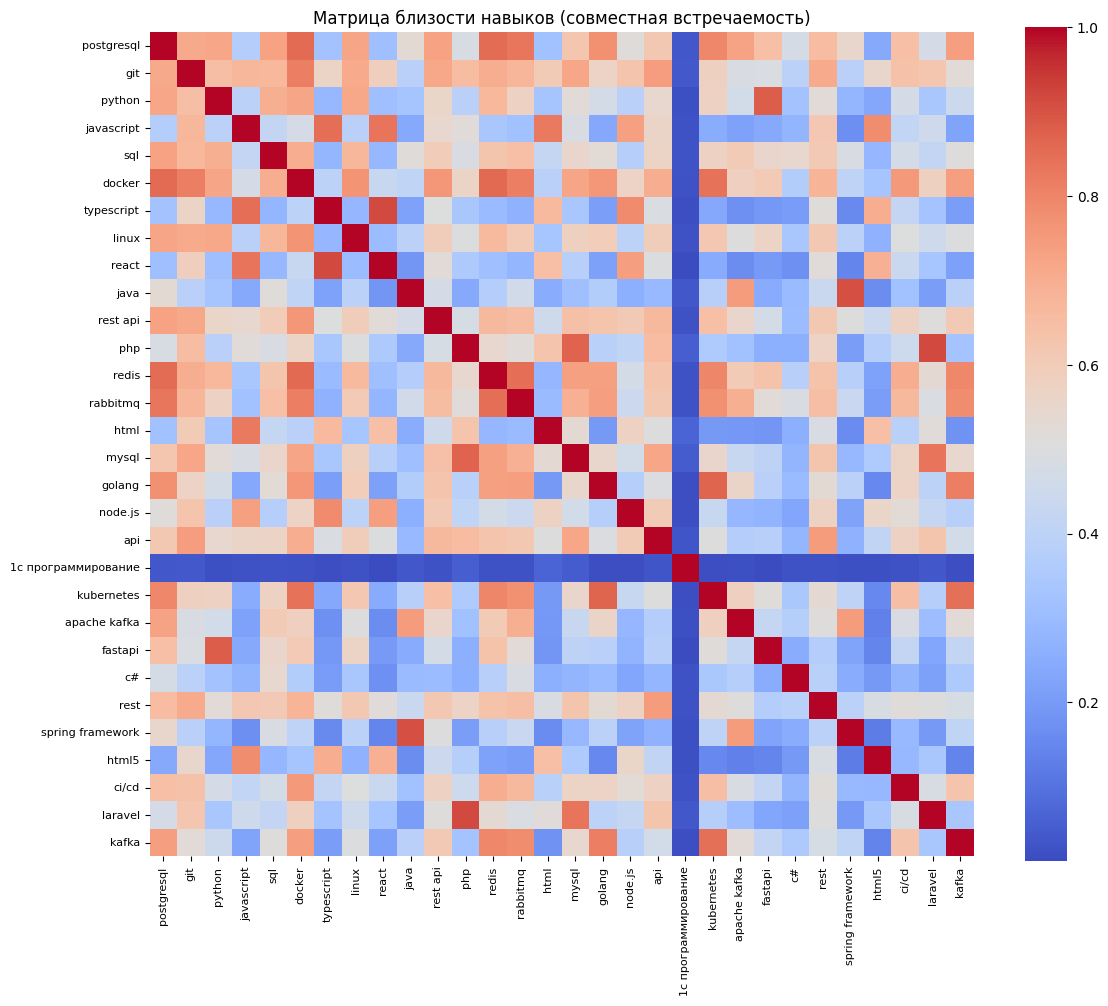

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Для наглядности возьмём только часть навыков (например, 30 самых частых)
top_n_display = 30
skills_subset = top_skills[:top_n_display]
similarity_subset = skill_similarity[:top_n_display, :top_n_display]

plt.figure(figsize=(12, 10))
sns.heatmap(similarity_subset, xticklabels=skills_subset, yticklabels=skills_subset,
            cmap='coolwarm', annot=False, square=True)
plt.title('Матрица близости навыков (совместная встречаемость)')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('skill_similarity_heatmap.png', dpi=300)
plt.show()

Используемый профиль пользователя:
  javascript: уровень 5
  react: уровень 4
  html: уровень 3
  css: уровень 3
  git: уровень 4

--- Рекомендации (только модель, α=1.0) ---
1. postgresql: скор модели = 0.855
2. python: скор модели = 0.811
3. sql: скор модели = 0.784
4. docker: скор модели = 0.776
5. typescript: скор модели = 0.761

--- Рекомендации (гибрид, α=0.7) ---
1. postgresql: комбинированный скор = 0.771 (модель=0.855, близость=0.576)
2. docker: комбинированный скор = 0.740 (модель=0.776, близость=0.656)
3. typescript: комбинированный скор = 0.714 (модель=0.761, близость=0.604)
4. python: комбинированный скор = 0.712 (модель=0.811, близость=0.480)
5. sql: комбинированный скор = 0.698 (модель=0.784, близость=0.498)


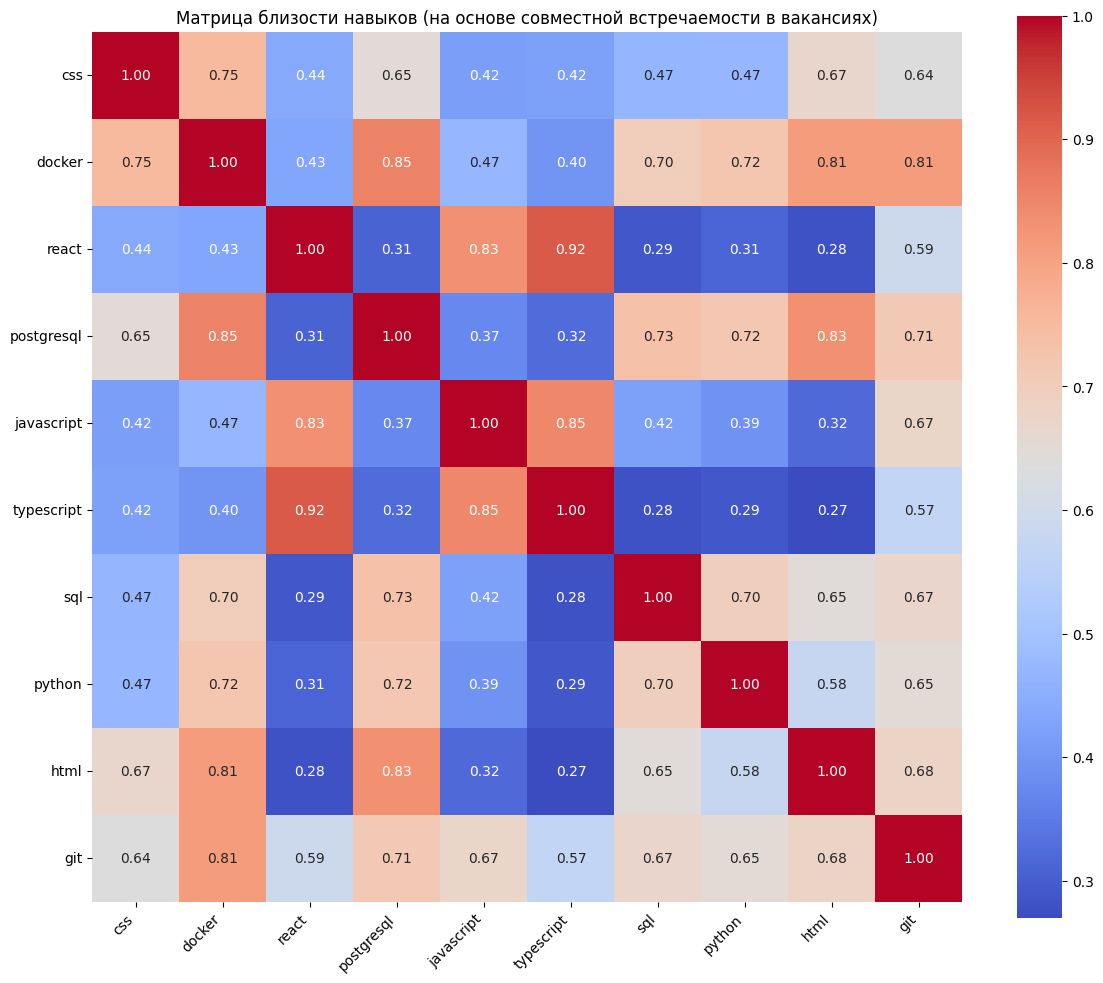

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Вручную задаём профиль пользователя
user_skills_manual = [
    ('javascript', 5),
    ('react', 4),
    ('html', 3),
    ('css', 3),
    ('git', 4)
]

# Проверяем наличие навыков в all_skills
valid_skills = []
skill_to_idx = {skill: i for i, skill in enumerate(all_skills)}
for skill, level in user_skills_manual:
    if skill in skill_to_idx:
        valid_skills.append((skill, level))
    else:
        print(f"Навык '{skill}' отсутствует в all_skills, пропускаем.")

print("Используемый профиль пользователя:")
for skill, level in valid_skills:
    print(f"  {skill}: уровень {level}")

# 2. Строим вектор навыков пользователя
user_vector = np.zeros(n_skills)
for skill, level in valid_skills:
    user_vector[skill_to_idx[skill]] = level

# Категориальные признаки (разработка, женский, возраст 25)
cat = 0
gen = 0
age_norm = 25 / 60.0
user_features = np.concatenate([user_vector, [cat, gen, age_norm]]).reshape(1, -1)

# 3. Получаем предсказания для всех навыков, которых нет или уровень <3
recommendations_model = []
recommendations_hybrid = []

for skill_idx, skill_name in enumerate(all_skills):
    current_level = user_vector[skill_idx]
    if current_level < 3:
        skill_feature = np.array([[freq_array[skill_idx]]])
        prob = model.predict([user_features, skill_feature], verbose=0)[0][0]

        # Средняя близость к уже имеющимся навыкам
        existing_indices = [skill_to_idx[s] for s, _ in valid_skills if s in skill_to_idx]
        if existing_indices:
            similarities = [skill_similarity[skill_idx, ex_idx] for ex_idx in existing_indices]
            avg_similarity = np.mean(similarities)
        else:
            avg_similarity = 0.0

        recommendations_model.append((skill_name, prob))
        recommendations_hybrid.append((skill_name, 0.7 * prob + 0.3 * avg_similarity, prob, avg_similarity))

# Сортировка
recommendations_model.sort(key=lambda x: x[1], reverse=True)
recommendations_hybrid.sort(key=lambda x: x[1], reverse=True)

print("\n--- Рекомендации (только модель, α=1.0) ---")
for i, (skill, score) in enumerate(recommendations_model[:5], 1):
    print(f"{i}. {skill}: скор модели = {score:.3f}")

print("\n--- Рекомендации (гибрид, α=0.7) ---")
for i, (skill, total, model_score, sim) in enumerate(recommendations_hybrid[:5], 1):
    print(f"{i}. {skill}: комбинированный скор = {total:.3f} (модель={model_score:.3f}, близость={sim:.3f})")

# 4. Тепловая карта для релевантных навыков
relevant_skills = set([s for s, _ in valid_skills] +
                      [r[0] for r in recommendations_model[:5]] +
                      [r[0] for r in recommendations_hybrid[:5]])
relevant_indices = [skill_to_idx[s] for s in relevant_skills if s in skill_to_idx]
relevant_names = [all_skills[i] for i in relevant_indices]
sub_sim = skill_similarity[np.ix_(relevant_indices, relevant_indices)]

plt.figure(figsize=(12, 10))
sns.heatmap(sub_sim, xticklabels=relevant_names, yticklabels=relevant_names,
            cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.title('Матрица близости навыков (на основе совместной встречаемости в вакансиях)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('skill_similarity_example.png', dpi=300)
plt.show()

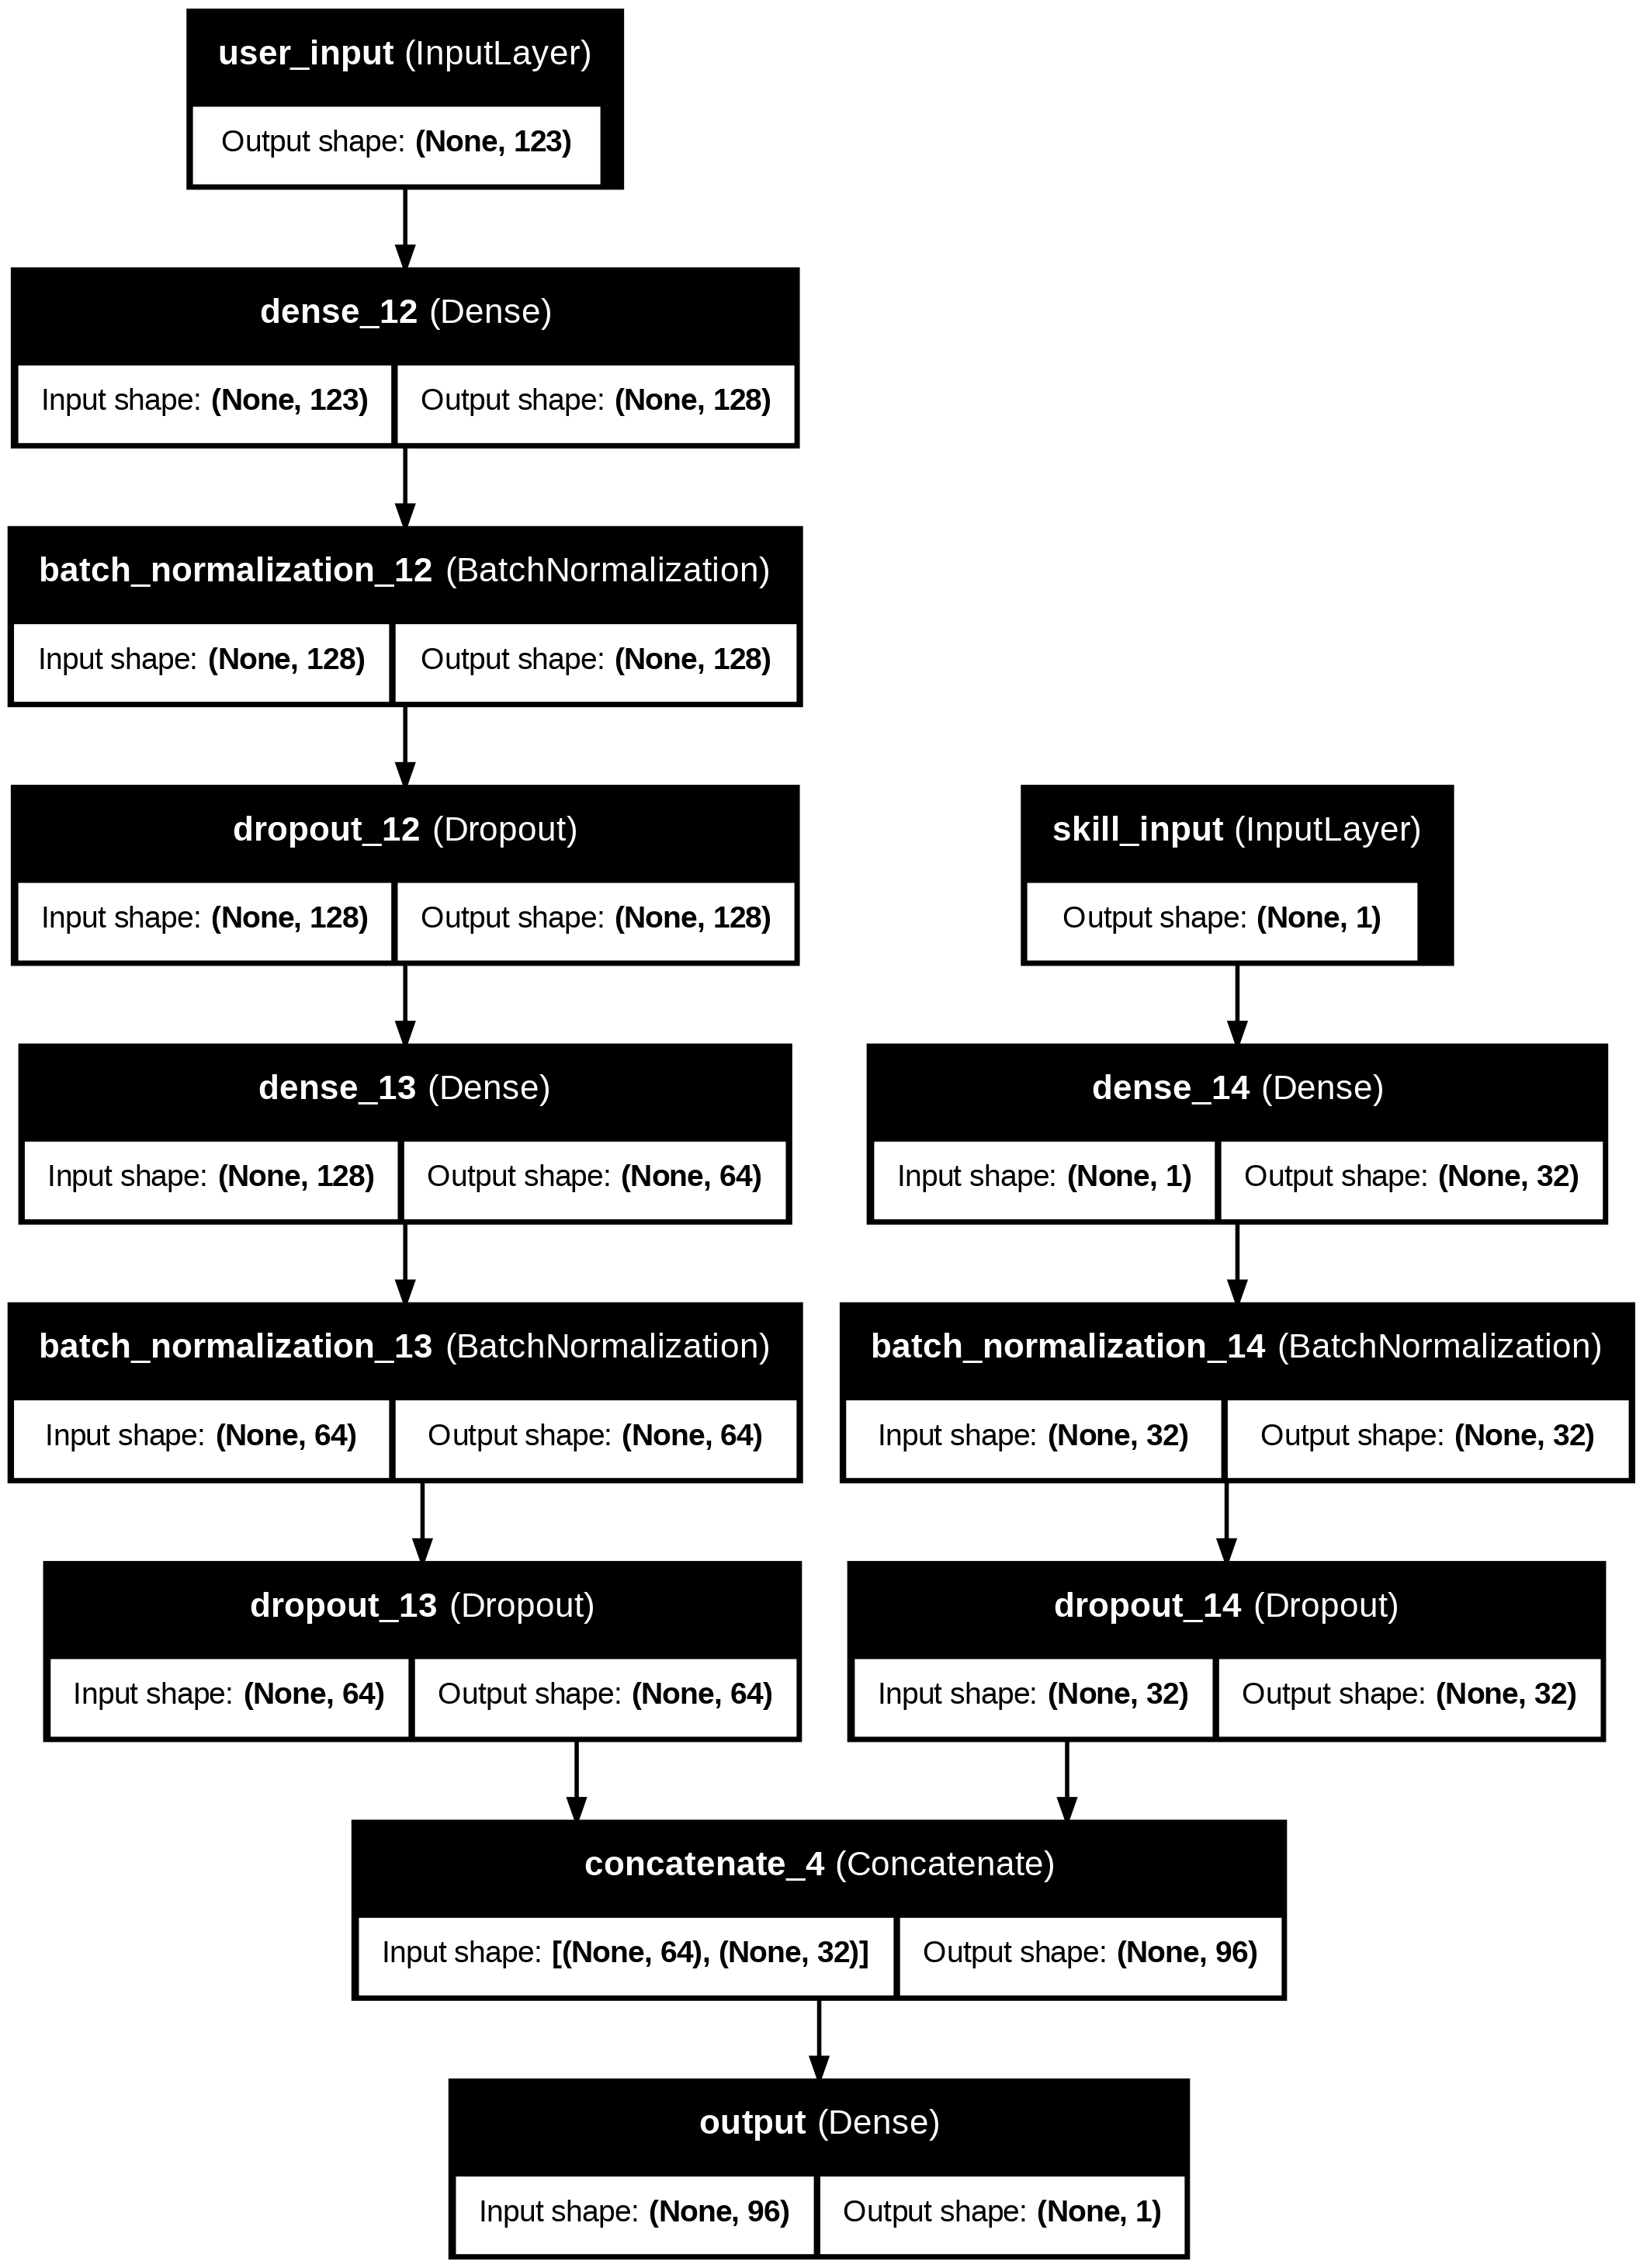

In [ ]:
tf.keras.utils.plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)